# **Análise da Eficiência Operacional da Uber**
**Autor: Luiz Almeida**

**Data: 26 de Setembro de 2025**

## **Introdução: O Problema de Negócio**
- Este projeto analisa um conjunto de dados de 150.000 corridas da Uber para identificar os principais fatores que levam a falhas operacionais (corridas não completadas). O objetivo final é extrair insights acionáveis que possam ajudar a empresa a melhorar sua taxa de sucesso, otimizar a alocação de recursos e aprimorar a experiência de clientes e motoristas.

## **1. Importação e Preparação dos Dados**
> O primeiro passo é carregar as bibliotecas essenciais para a análise e manipulação de dados, bem como o nosso dataset. Em seguida, realizamos a limpeza e transformação inicial dos dados para torná-los úteis para a análise, com foco principal no tratamento de datas e horas.

In [1]:
# Importação de Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_style("whitegrid")

In [2]:
# Carregamento e Limpeza Inicial dos Dados
# Carregar o dataset
caminho_arquivo = '/kaggle/input/uber-ride-analytics-dashboard/ncr_ride_bookings.csv'
df = pd.read_csv(caminho_arquivo)

# Converter colunas de data e hora para um único campo datetime
df['request_datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Remover as colunas originais e redundantes
df = df.drop(['Date', 'Time'], axis=1)

print("Dados carregados e limpeza inicial concluída.")
print(f"O dataset contém {df.shape[0]} linhas e {df.shape[1]} colunas.")

Dados carregados e limpeza inicial concluída.
O dataset contém 150000 linhas e 20 colunas.


## **2. Análise Exploratória Inicial (EDA)**
> Antes de aprofundar a análise, é crucial entender a estrutura básica dos dados. Verificamos a distribuição dos status das corridas e a quantidade de dados ausentes em cada coluna para guiar os próximos passos.

In [3]:
# Análise de Status de Corrida e Dados Ausentes
print("--- Contagem dos diferentes 'Booking Status' ---")
display(df['Booking Status'].value_counts())

print("\n--- Porcentagem de valores ausentes por coluna ---")
missing_values_percentage = (df.isnull().sum() / len(df)) * 100
display(missing_values_percentage.sort_values(ascending=False))

--- Contagem dos diferentes 'Booking Status' ---


Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


--- Porcentagem de valores ausentes por coluna ---


Incomplete Rides Reason              94.0
Incomplete Rides                     94.0
Cancelled Rides by Customer          93.0
Reason for cancelling by Customer    93.0
Cancelled Rides by Driver            82.0
Driver Cancellation Reason           82.0
Customer Rating                      38.0
Driver Ratings                       38.0
Payment Method                       32.0
Ride Distance                        32.0
Avg CTAT                             32.0
Booking Value                        32.0
Avg VTAT                              7.0
Booking ID                            0.0
Booking Status                        0.0
Drop Location                         0.0
Pickup Location                       0.0
Vehicle Type                          0.0
Customer ID                           0.0
request_datetime                      0.0
dtype: float64

- Observação: A grande quantidade de valores ausentes em colunas de "razão" (Reason) é esperada, pois só se aplicam a corridas incompletas ou canceladas. A hipótese inicial é que os demais dados ausentes (distância, avaliação, etc.) ocorrem em corridas não completadas.

## **3. Engenharia de Features e Análise Temporal**
> Para entender os padrões baseados no tempo, extraímos informações úteis (features) da nossa coluna request_datetime. Isso nos permite analisar a demanda e as operações por hora, dia da semana e mês.

In [4]:
# Célula 4: Engenharia de Features de Tempo
df['hour_of_day'] = df['request_datetime'].dt.hour
df['day_of_week'] = df['request_datetime'].dt.day_name()
df['month'] = df['request_datetime'].dt.month

print("Novas colunas de tempo ('hour_of_day', 'day_of_week', 'month') criadas com sucesso.")

Novas colunas de tempo ('hour_of_day', 'day_of_week', 'month') criadas com sucesso.


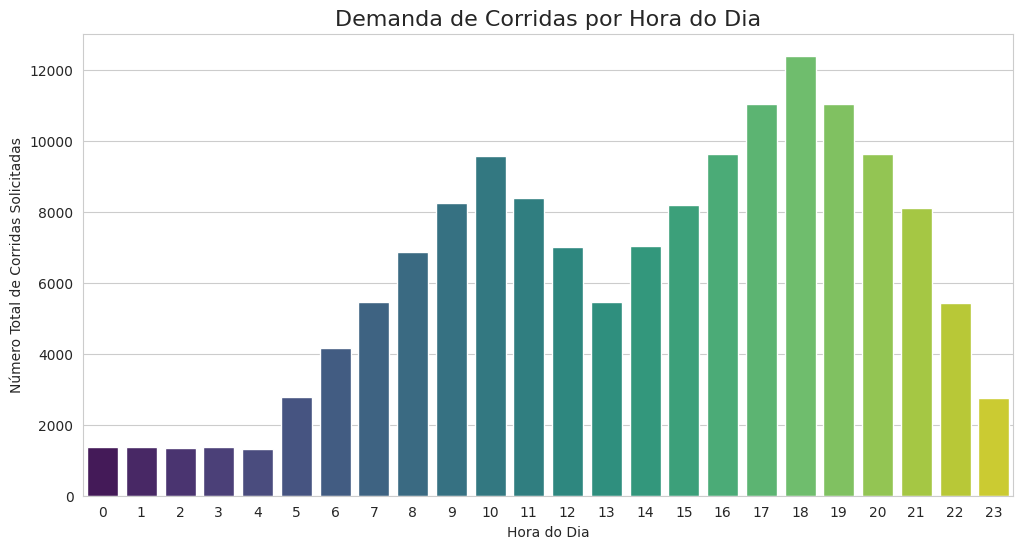

In [5]:
# Célula 5: Visualização da Demanda por Hora do Dia
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='hour_of_day', palette='viridis')
plt.title('Demanda de Corridas por Hora do Dia', fontsize=16)
plt.ylabel('Número Total de Corridas Solicitadas')
plt.xlabel('Hora do Dia')
plt.show()

- Insight: O gráfico revela um padrão claro com dois picos de demanda: um matinal (7h-10h) e um noturno, muito mais forte (16h-20h), correspondendo aos horários de deslocamento diário.

## **4. Análise dos Fatores de Falha**
> O foco principal do projeto é entender o que leva uma corrida a falhar. Para isso, criamos uma categoria binária ("Success" vs "Failure") e cruzamos essa informação com os fatores temporais e de serviço.

In [6]:
# Criação da Categoria Binária de Sucesso/Falha
df['status_group'] = df['Booking Status'].apply(lambda x: 'Success' if x == 'Completed' else 'Failure')

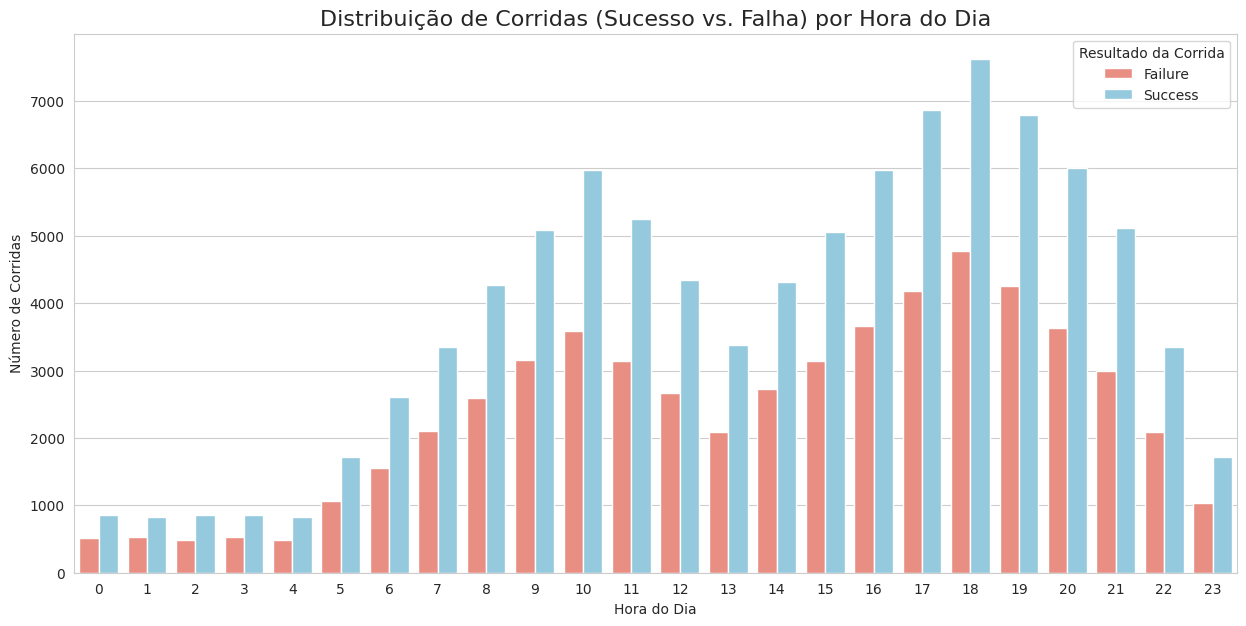

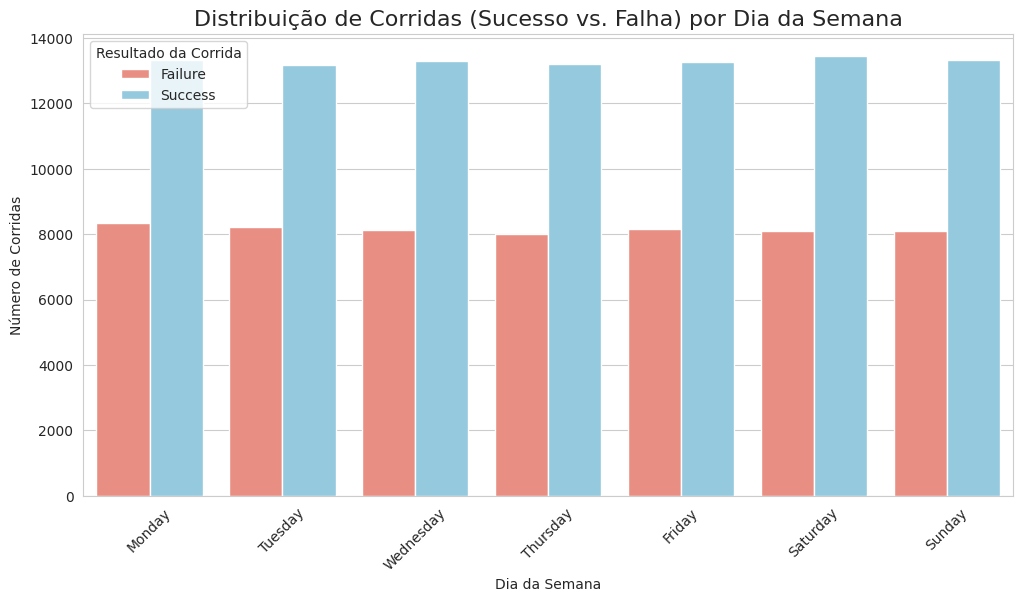

In [7]:
# Análise de Falhas por Hora do Dia e Dia da Semana
# Gráfico 1: Sucesso vs. Falha por Hora do Dia
plt.figure(figsize=(15, 7))
sns.countplot(data=df, x='hour_of_day', hue='status_group', palette={'Success': 'skyblue', 'Failure': 'salmon'})
plt.title('Distribuição de Corridas (Sucesso vs. Falha) por Hora do Dia', fontsize=16)
plt.ylabel('Número de Corridas')
plt.xlabel('Hora do Dia')
plt.legend(title='Resultado da Corrida')
plt.show()

# Gráfico 2: Sucesso vs. Falha por Dia da Semana
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='day_of_week', hue='status_group', order=week_order, palette={'Success': 'skyblue', 'Failure': 'salmon'})
plt.title('Distribuição de Corridas (Sucesso vs. Falha) por Dia da Semana', fontsize=16)
plt.ylabel('Número de Corridas')
plt.xlabel('Dia da Semana')
plt.xticks(rotation=45)
plt.legend(title='Resultado da Corrida')
plt.show()

- Insight: O volume de falhas acompanha os picos de demanda, sugerindo uma sobrecarga do sistema. Surpreendentemente, a proporção de sucesso/falha é bastante estável ao longo dos dias da semana.

## **5. Análise Geográfica e por Tipo de Serviço**
> Investigamos se o local de partida ou o tipo de veículo são fatores determinantes para a falha de uma corrida.

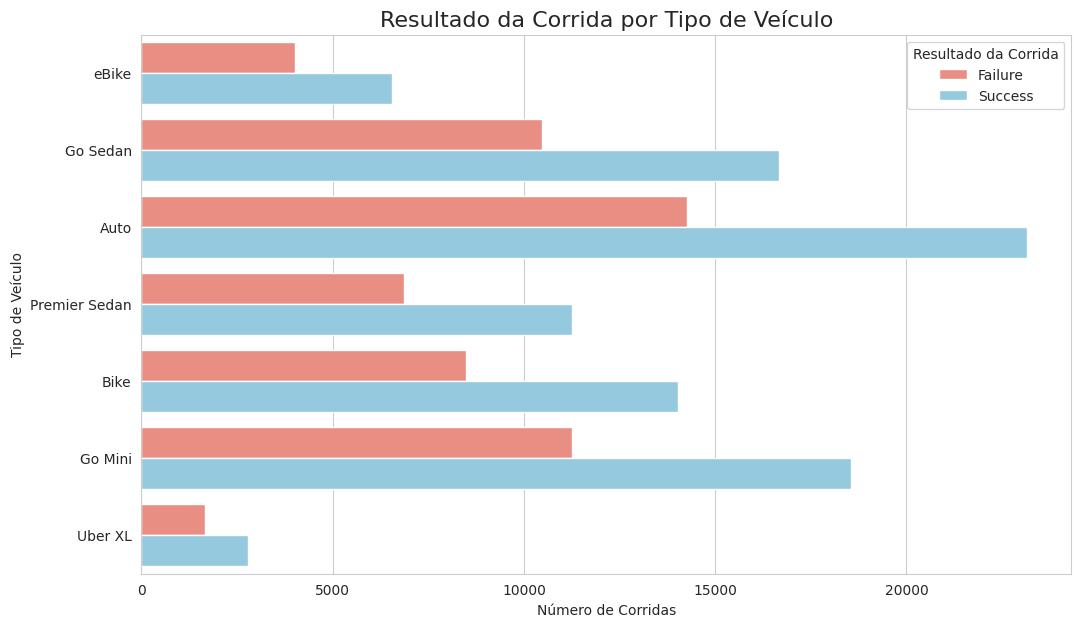

In [8]:
# Análise de Falhas por Tipo de Veículo
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='Vehicle Type', hue='status_group', palette={'Success': 'skyblue', 'Failure': 'salmon'})
plt.title('Resultado da Corrida por Tipo de Veículo', fontsize=16)
plt.xlabel('Número de Corridas')
plt.ylabel('Tipo de Veículo')
plt.legend(title='Resultado da Corrida')
plt.show()

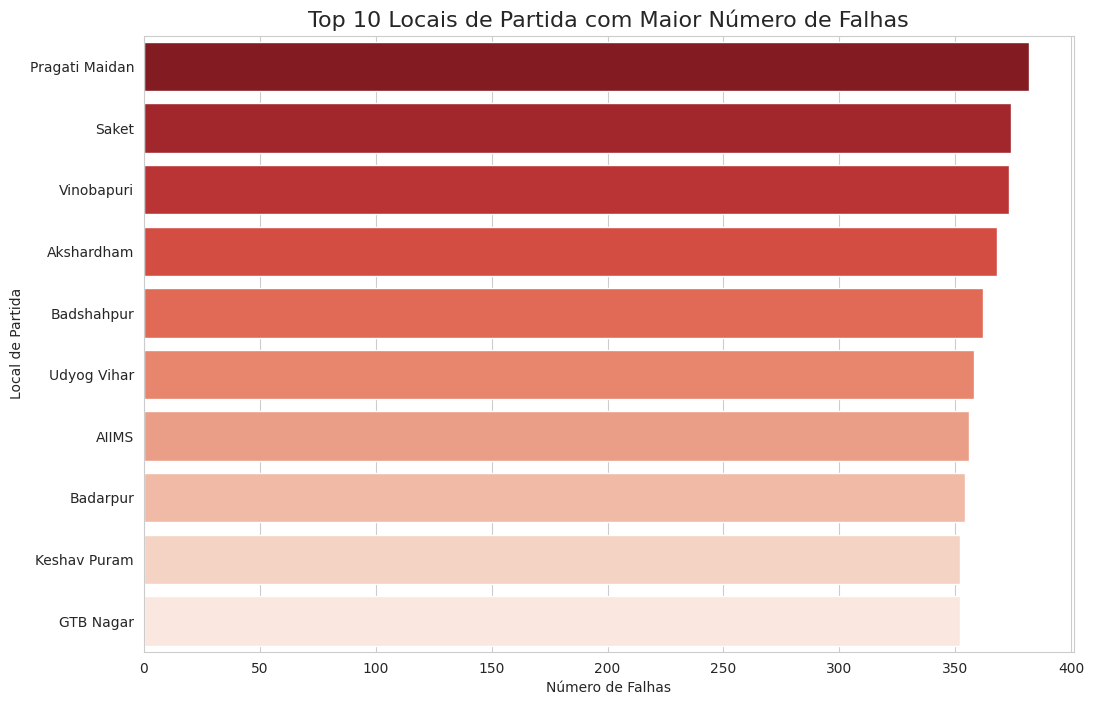

In [9]:
# Identificação dos "Hotspots" de Falha (Locais)
# Filtramos apenas as corridas que falharam
df_failures = df[df['status_group'] == 'Failure']

# Contamos os locais de partida mais frequentes nessa lista de falhas
top_10_failure_locations = df_failures['Pickup Location'].value_counts().head(10)

# Visualizamos o Top 10
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_failure_locations.values, y=top_10_failure_locations.index, palette='Reds_r')
plt.title('Top 10 Locais de Partida com Maior Número de Falhas', fontsize=16)
plt.xlabel('Número de Falhas')
plt.ylabel('Local de Partida')
plt.show()

## **6. Conclusões Quantitativas e Recomendações**
> Para finalizar, calculamos as taxas de falha exatas para solidificar nossas descobertas e embasar as recomendações de negócio.

In [10]:
# Cálculo da Taxa de Falha por Tipo de Veículo
print("--- Taxa de Falha (%) por Tipo de Veículo ---")
failure_rate_by_vehicle = pd.crosstab(df['Vehicle Type'], df['status_group'], normalize='index') * 100
display(failure_rate_by_vehicle.sort_values(by='Failure', ascending=False).style.format('{:.2f}%'))

--- Taxa de Falha (%) por Tipo de Veículo ---


status_group,Failure,Success
Vehicle Type,,
Go Sedan,38.56%,61.44%
Auto,38.12%,61.88%
eBike,37.95%,62.05%
Premier Sedan,37.87%,62.13%
Go Mini,37.77%,62.23%
Bike,37.67%,62.33%
Uber XL,37.45%,62.55%


In [11]:
# Cálculo da Taxa de Falha para os Top 10 Locais
print("\n--- Taxa de Falha (%) para os Top 10 Locais de Falha ---")
total_rides_top_locations = df[df['Pickup Location'].isin(top_10_failure_locations.index)]['Pickup Location'].value_counts()
failure_rate_top_locations = (top_10_failure_locations / total_rides_top_locations) * 100
display(failure_rate_top_locations.sort_values(ascending=False).to_frame(name='Failure Rate (%)').style.format('{:.2f}%'))


--- Taxa de Falha (%) para os Top 10 Locais de Falha ---


,Failure Rate (%)
Pickup Location,
Vinobapuri,45.32%
Akshardham,43.86%
Badshahpur,41.71%
Pragati Maidan,41.52%
Keshav Puram,40.69%
GTB Nagar,40.37%
Saket,40.17%
Udyog Vihar,39.91%
AIIMS,38.78%


- **Conclusão Final:** A análise prova que os principais impulsionadores da falha nas corridas são temporais (horários de pico) e, mais criticamente, geográficos. Locais como Vinobapuri e Akshardham não são apenas movimentados, mas sistemicamente ineficientes, com taxas de falha superiores a 43%. O tipo de veículo, por outro lado, não se mostrou um fator determinante.

- **Recomendação:** A Uber deve implementar um plano de ação geograficamente focado, oferecendo incentivos a motoristas nos "hotspots" durante os horários de pico e investigando as causas-raiz dos problemas nessas localidades.